# Structural Analysis and Interface Analysis for AlphaFold Server outputs

## Setup

### Install Libraries

In [44]:
%pip install -q biopython numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


### Imports

In [45]:
import os
import glob
import zipfile
import json
import re
import numpy as np
import pandas as pd
import warnings
import ipywidgets as widgets
import py3Dmol
import matplotlib.pyplot as plt
import seaborn as sns # Optional, but makes plots nicer

from Bio.PDB import MMCIFParser, NeighborSearch

# Import SASA calculator
from Bio.PDB.SASA import ShrakeRupley
from Bio import BiopythonWarning

# Suppress warnings
warnings.simplefilter('ignore', BiopythonWarning)
warnings.simplefilter('ignore', RuntimeWarning) # Suppress numpy means on empty slices

# Definitions
HYDROPHOBIC_RES = {'ALA', 'VAL', 'ILE', 'LEU', 'MET', 'PHE', 'TYR', 'TRP'}
POS_CHARGE_RES = {'ARG', 'LYS', 'HIS'}
NEG_CHARGE_RES = {'ASP', 'GLU'}

# Manual 3-to-1 mapping
AA_MAP = {
    'ALA': 'A', 'CYS': 'C', 'ASP': 'D', 'GLU': 'E', 'PHE': 'F',
    'GLY': 'G', 'HIS': 'H', 'ILE': 'I', 'LYS': 'K', 'LEU': 'L',
    'MET': 'M', 'ASN': 'N', 'PRO': 'P', 'GLN': 'Q', 'ARG': 'R',
    'SER': 'S', 'THR': 'T', 'VAL': 'V', 'TRP': 'W', 'TYR': 'Y'
}

# Regex to extract variant. Assumes format: Ligand_Target_VARIANT_...
# It looks for the text between the 2nd and 3rd underscore.

print("Libraries and definitions loaded.")

Libraries and definitions loaded.


### Filename Parser

In [46]:
# Current Format: fold_{ligand}_vs_{target}_{loop_id}_{variant}_{...}.zip
def parse_filename(filename):
    """
    Parses the filename to extract Target, Loop, and Variant.
    """
    # Remove extension
    name = filename.replace('.zip', '')
    
    # Split by underscore
    parts = name.split('_')
    
    # Safety Check: Ensure filename has enough parts
    if len(parts) < 6:
        return {"ligand": "Unknown", "target": "Unknown", "loop": "Unknown", "variant": "Unknown"}

    # --- UPDATED INDICES MAPPING ---
    # [0] = fold
    # [1] = {ligand}
    # [2] = vs
    # [3] = {target} 
    # [4] = {loop_id}
    # [5] = {variant}
    
    extracted = {
        "ligand": parts[1],  # Index 1
        "target": parts[3],  # Index 3
        "loop":   parts[4],  # Index 4
        "variant": parts[5]  # Index 5
    }
    return extracted

### Configuration

In [47]:
# --- CONFIGURATION 1: TARGET DEFINITIONS ---
# Key: Part of the filename (e.g., "MMP9")
# Value: The amino acid sequence of the active site
TARGET_DB = {
    "adam10": "HEVGHNFGSPHD",
    "adam17": "HELGHNFGAEHD",
    "mmp2": "HEFGHAMGLEHS", 
    "mmp9": "HEFGHALGLDHS" 
}

# --- CONFIGURATION 2: LIGAND LOOP DEFINITIONS ---
# Key: The 'loop_id' found in the filename (e.g., "L1", "LoopA")
# Value: List of residue numbers to focus on in Chain A
LOOP_DEFAULTS = {
    "ab": {"start_residue": 30,  "wt_length": 36}, 
    "c":    {"start_residue": 62,  "wt_length": 68},
    "ef": {"start_residue": 92, "wt_length": 96} 
}

# Folder containing your zips
INPUT_FOLDER = "../Local/AlphaFoldRun" 
OUTPUT_FOLDER = "../Local"

print("Configuration loaded.")

Configuration loaded.


## Interaction Analysis

### Function definitions

In [48]:
def get_chain_sequence_and_ids(chain):
    """
    Robustly extracts sequence and residue IDs from a PDB Chain.
    Uses a manual dictionary to map 3-letter codes to 1-letter.
    """
    seq_string = ""
    res_id_list = []
    
    for res in chain:
        # res.id[0] is ' ' for standard atoms. 
        # We skip heteroatoms (H_) and waters (W)
        if res.id[0] != ' ':
            continue
            
        res_name = res.get_resname()
        
        # Check if it's a standard amino acid in our map
        if res_name in AA_MAP:
            seq_string += AA_MAP[res_name]
            res_id_list.append(res.get_id()[1])
        else:
            # If it's a non-standard AA, we skip it to prevent indexing errors
            continue

    return seq_string, res_id_list

def find_active_site_ids(chain, motif_seq):
    """Finds residue numbers of the motif in the target chain."""
    full_seq, ids = get_chain_sequence_and_ids(chain)
    
    # Debug print: Uncomment if you suspect the sequence isn't being found
    # print(f"DEBUG: Target Chain Seq (First 10): {full_seq[:10]}") 
    
    start_idx = full_seq.find(motif_seq)
    if start_idx == -1:
        return None
    
    end_idx = start_idx + len(motif_seq)
    
    # Ensure we don't go out of bounds (though find() usually prevents this)
    if end_idx > len(ids):
        return None
        
    return ids[start_idx:end_idx]

def get_dynamic_roi(loop_name, variant_str):
    """
    Calculates the ROI based on the loop start position and variant length.
    Handles 'wt' case.
    """
    # 1. Get defaults
    config = LOOP_DEFAULTS.get(loop_name)
    if not config:
        return None
    
    start = config['start_residue']
    
    # 2. Determine Length
    if variant_str.lower() == "wt":
        length = config['wt_length']
    else:
        # Assuming the variant string in filename IS the sequence (e.g., "ACDEF")
        length = len(variant_str)
        
    # 3. Create Range (Start to Start + Length)
    # Python range is exclusive at the end, so start+length is correct
    return range(start, start + length)

def calculate_pae_subset(json_data, l_len, t_len):
    """Extracts the Ligand-on-Target error block."""
    if 'pae' not in json_data: return 100.0
    full_pae = np.array(json_data['pae'])
    
    # Extract interaction block: Ligand rows, Target columns
    # We assume the matrix size matches l_len + t_len. 
    # If the matrix is bigger (e.g. multimer with extra copies), we take the top-left block interaction.
    try:
        sub_matrix = full_pae[0:l_len, l_len:l_len+t_len]
        return np.mean(sub_matrix)
    except IndexError:
        return 100.0 # Return high error if dimensions don't match

def calculate_sasa(structure, chain_l, chain_t):
    """
    Calculates Buried Surface Area (Interface Area).
    BSA = (SASA_A + SASA_B) - SASA_Complex
    Standard SASA calculation can be slow on large structures.
    """
    sr = ShrakeRupley()
    
    # 1. Calculate SASA for the whole complex
    sr.compute(structure, level="S")
    sasa_complex = structure.sasa
    
    # 2. To get SASA of individual chains, we must detach them temporarily
    # Detach Target from Model to calculate Ligand alone
    model = structure[0]
    model.detach_child(chain_t.id)
    sr.compute(structure, level="S")
    sasa_l_alone = structure.sasa
    
    # Re-attach Target, detach Ligand
    model.add(chain_t)
    model.detach_child(chain_l.id)
    sr.compute(structure, level="S")
    sasa_t_alone = structure.sasa
    
    # Re-attach Ligand to restore structure object for later use
    model.add(chain_l)
    
    # Buried Area is the difference. We divide by 2 for interface area.
    buried_area = (sasa_l_alone + sasa_t_alone) - sasa_complex
    return round(buried_area / 2.0, 2)

def calculate_geometry(cif_path, ligand_roi, target_site_ids):
    """Calculates H-bonds, Salt Bridges, Clashes, Contacts."""
    parser = MMCIFParser(QUIET=True)
    structure = parser.get_structure("temp", cif_path)
    model = structure[0]
    
    try:
        chain_l = model['A']
        chain_t = model['B']
    except KeyError: return None

    # --- Resolve Atoms based on ROIs ---
    if target_site_ids:
        t_res_list = [r for r in chain_t if r.get_id()[1] in target_site_ids]
    else:
        t_res_list = [r for r in chain_t if r.id[0] == ' ']

    if ligand_roi:
        l_res_list = [r for r in chain_l if r.get_id()[1] in ligand_roi]
    else:
        l_res_list = [r for r in chain_l if r.id[0] == ' ']
        
    t_atoms = [a for r in t_res_list for a in r]
    l_atoms = [a for r in l_res_list for a in r]

    if not l_atoms or not t_atoms: return None

    # --- Main Calculations ---
    ns = NeighborSearch(t_atoms)
    stats = {"h_bonds": 0, "salt_bridges": 0, "hydrophobic": 0, "clashes": 0, "plddt": []}
    
    for l_atom in l_atoms:
        stats["plddt"].append(l_atom.bfactor)
        # Search slightly wider for Salt bridges (4.0A)
        neighbors = ns.search(l_atom.get_coord(), 4.0)
        
        l_res = l_atom.get_parent()
        l_resname = l_res.get_resname()
        
        for t_atom in neighbors:
            dist = l_atom - t_atom
            t_res = t_atom.get_parent()
            t_resname = t_res.get_resname()

            # A. Clashes (very close contact)
            if dist < 1.5: stats["clashes"] += 1
            
            # B. H-Bond (Geometric approx: < 3.5A and N/O atoms)
            if dist < 3.5 and l_atom.element in ['N','O'] and t_atom.element in ['N','O']:
                stats["h_bonds"] += 1
            
            # C. Hydrophobic Contact (< 4.0A)
            if dist < 4.0 and l_resname in HYDROPHOBIC_RES and t_resname in HYDROPHOBIC_RES:
                stats["hydrophobic"] += 1
                
            # D. Salt Bridges (< 4.0A between oppositely charged residues)
            # Check Ligand Positive <-> Target Negative
            if (l_resname in POS_CHARGE_RES and t_resname in NEG_CHARGE_RES):
                 if l_atom.name.startswith(('NZ', 'NH', 'ND')) and t_atom.name.startswith(('OD', 'OE')):
                     stats["salt_bridges"] += 1
            # Check Ligand Negative <-> Target Positive
            elif (l_resname in NEG_CHARGE_RES and t_resname in POS_CHARGE_RES):
                 if l_atom.name.startswith(('OD', 'OE')) and t_atom.name.startswith(('NZ', 'NH', 'ND')):
                     stats["salt_bridges"] += 1

    # --- SASA Calculation (Expensive, run once per structure) ---
    # We calculate SASA for the whole interface, not just the ROI, for overall context
    sasa_val = calculate_sasa(structure, chain_l, chain_t)
    stats["bsa"] = sasa_val
    
    return stats, len(chain_l), len(chain_t)

### Main Pipeline

In [49]:
data_rows = []
cif_paths_map = {} # Used for the visualizer later

zip_files = glob.glob(os.path.join(INPUT_FOLDER, "*.zip"))
print(f"Found {len(zip_files)} zip files. Starting analysis...")
print("Note: SASA calculations may take a moment per file.")

for i, z_path in enumerate(zip_files):
    base_name = os.path.basename(z_path)
    if i % 10 == 0: print(f"Processing {i}/{len(zip_files)}: {base_name}")
    
    # --- Extract Metadata ---
    metadata = parse_filename(base_name)
    
    target_name = metadata['target']
    loop_name = metadata['loop']
    variant_name = metadata['variant']
    
    # Get Configs based on extracted names
    # Defaults to None if name not in DB
    current_target_seq = TARGET_DB.get(target_name)
    current_ligand_roi = get_dynamic_roi(loop_name, variant_name)
    
    # --- Process File ---
    try:
        with zipfile.ZipFile(z_path, 'r') as z:
            file_list = z.namelist()
            cif_file = next((f for f in file_list if "_model_0.cif" in f), None)
            conf_file = next((f for f in file_list if "_summary_confidences_0.json" in f), None)
            pae_file = next((f for f in file_list if "_full_data_0.json" in f), None)
            
            if not (cif_file and conf_file and pae_file):
                print(f"Skipping {base_name}: Missing rank 0 files")
                continue

            with z.open(conf_file) as f: conf_data = json.load(f)
            with z.open(pae_file) as f: pae_data = json.load(f)
            with z.open(cif_file) as f:
                cif_content = f.read()
                with open("temp_nb.cif", "wb") as temp: temp.write(cif_content)
            
            # --- Run Analysis ---
            # Resolve Target Position
            parser = MMCIFParser(QUIET=True)
            temp_struct = parser.get_structure("temp", "temp_nb.cif")
            target_ids = None
            if current_target_seq:
                try:
                    target_chain = temp_struct[0]['B']
                    target_ids = find_active_site_ids(target_chain, current_target_seq)
                except Exception: pass

            # Run Geometry Checks (includes SASA now)
            geo_res = calculate_geometry("temp_nb.cif", current_ligand_roi, target_ids)
            if not geo_res: continue
            stats, l_len, t_len = geo_res
            
            # Run PAE Check
            inter_pae = calculate_pae_subset(pae_data, l_len, t_len)

            # Get ipTM
            iptm_score = conf_data.get('iptm', 0.0)

            '''
            ## Generic weights
            # Bonus for Salt Bridges
            sb_bonus = min(stats["salt_bridges"] * 0.05, 0.15) # Max 15% bonus
            comp_prob = (iptm_score * 0.5) + (min(stats["h_bonds"],10)/10 * 0.3) + (max(0,(15-inter_pae)/15) * 0.2) + sb_bonus
            comp_prob = min(comp_prob * 100, 100)
            '''

            ### WEIGHTS FOR TIMP ###

            # H-Bonds: Cap at 15 (TIMP interfaces are large)
            hb_score = min(stats["h_bonds"], 15) / 15.0
            
            # PAE: Low error is good. Normalize 0-15 Angstroms.
            pae_score = max(0, (15 - inter_pae) / 15.0)
            
            # BSA (Buried Surface Area): CRITICAL FOR TIMPS
            # A good TIMP interface usually buries >600 A^2. We cap at 1000 for max score.
            # If BSA is < 400, it's likely a weak/transient contact.
            bsa_score = min(stats["bsa"], 1000) / 1000.0
            
            # 2. Calculate Weighted Probability
            # ipTM (35%) + BSA (25%) + PAE (20%) + H-Bonds (20%)
            comp_prob = (iptm_score * 0.35) + \
                        (bsa_score * 0.25) + \
                        (pae_score * 0.20) + \
                        (hb_score * 0.20)
            
            # 3. Apply Bonuses
            # Salt Bridge Bonus (Max 10%)
            sb_bonus = min(stats["salt_bridges"] * 0.02, 0.10)
            
            # Hydrophobic Packing Bonus (Max 5%)
            # High hydrophobic contacts indicate the "Wedge" is burying properly
            hydro_bonus = min(stats["hydrophobic"] * 0.01, 0.05)
            
            # Final Sum
            comp_prob = (comp_prob + sb_bonus + hydro_bonus) * 100
            comp_prob = min(comp_prob, 100) # Cap at 100

            #########################

            # Save results
            row_data = {
                "Variant": variant_name,
                "Target": target_name,
                "Loop_ID": loop_name,
                "Prob_Score": round(comp_prob, 1),
                "ipTM": round(iptm_score, 2),
                "PAE_Int": round(inter_pae, 2),
                "BSA(Å²)": stats["bsa"],
                "H_Bonds": stats["h_bonds"],
                "Salt_Bridges": stats["salt_bridges"],
                "Hydrophobic": stats["hydrophobic"],
                "Clashes": stats["clashes"],
                "Filename": base_name
            }
            data_rows.append(row_data)
            
            # Store CIF content in memory for the visualizer later
            cif_paths_map[base_name] = cif_content.decode('utf-8')

    except Exception as e:
        print(f"Failed on {base_name}: {e}")

if os.path.exists("temp_nb.cif"): os.remove("temp_nb.cif")
df = pd.DataFrame(data_rows)
df = df.sort_values("Prob_Score", ascending=False)
print("Processing Complete.")

Found 549 zip files. Starting analysis...
Note: SASA calculations may take a moment per file.
Processing 0/549: fold_timp3_variant_adam10_ab_wt.zip
Processing 10/549: fold_timp3_variant_mmp9_c_wt.zip
Processing 20/549: fold_timp3_vs_adam10_ab_egpvge_proteinmpnn_vmmp9.zip
Processing 30/549: fold_timp3_vs_adam10_ab_kekvgdkevlk_rfd_01_abexp_vadam17.zip
Processing 40/549: fold_timp3_vs_adam10_ab_kgpegaagdl_rfd_02_abexp_vmmp9.zip
Processing 50/549: fold_timp3_vs_adam10_ab_klfdektgktiye_rfd_01_abexp_vadam17.zip
Processing 60/549: fold_timp3_vs_adam10_ab_sgptgt_proteinmpnn_vmmp9.zip
Processing 70/549: fold_timp3_vs_adam10_ab_ynketggye_rfd_01_abexp_vmmp9.zip
Processing 80/549: fold_timp3_vs_adam10_c_anpeyc_proteinmpnn_vmmp9.zip
Processing 90/549: fold_timp3_vs_adam10_c_asgpvtlpdgtviw_rfd_01_cexp_vadam17.zip
Processing 100/549: fold_timp3_vs_adam10_c_cvlengewkpapc_rfd_01_cexp_vmmp9.zip
Processing 110/549: fold_timp3_vs_adam10_c_sveslc_proteinmpnn_vmmp9.zip
Processing 120/549: fold_timp3_vs_adam

### Data Visualization 

Top 10 Candidates by Probability Score:


,Variant,Target,Loop_ID,Prob_Score,ipTM,PAE_Int,BSA(Å²),H_Bonds,Salt_Bridges,Hydrophobic,Clashes,Filename
353,anthlc,mmp2,c,72.2,0.84,8.13,1166.35,5,1,0,0,fold_timp3_vs_mmp2_c_anthlc_proteinmpnn_vadam1...
7,wt,mmp2,c,72.2,0.83,8.91,1279.52,3,3,0,0,fold_timp3_variant_mmp2_c_wt.zip
110,sveslc,adam10,c,70.9,0.89,7.41,1367.29,2,1,0,0,fold_timp3_vs_adam10_c_sveslc_proteinmpnn_vmmp...
346,anehlc,mmp2,c,69.6,0.84,8.07,1239.36,3,1,0,0,fold_timp3_vs_mmp2_c_anehlc_proteinmpnn_vadam1...
108,sveelc,adam10,c,69.2,0.88,7.47,1414.38,1,1,0,0,fold_timp3_vs_adam10_c_sveelc_proteinmpnn_vmmp...
75,anealc,adam10,c,69.1,0.88,7.49,1397.85,1,1,0,0,fold_timp3_vs_adam10_c_anealc_proteinmpnn_vada...
345,aneglc,mmp2,c,68.9,0.84,8.15,1172.10,4,0,0,0,fold_timp3_vs_mmp2_c_aneglc_proteinmpnn_vadam1...
96,aveeyc,adam10,c,68.8,0.88,7.76,1279.00,1,1,0,0,fold_timp3_vs_adam10_c_aveeyc_proteinmpnn_vmmp...
76,aneglc,adam10,c,68.8,0.88,7.72,1378.25,1,1,0,0,fold_timp3_vs_adam10_c_aneglc_proteinmpnn_vada...
109,sveeyc,adam10,c,68.5,0.88,8.00,1374.64,1,1,0,0,fold_timp3_vs_adam10_c_sveeyc_proteinmpnn_vmmp...


Full results saved to af_batch_results_detailed.csv


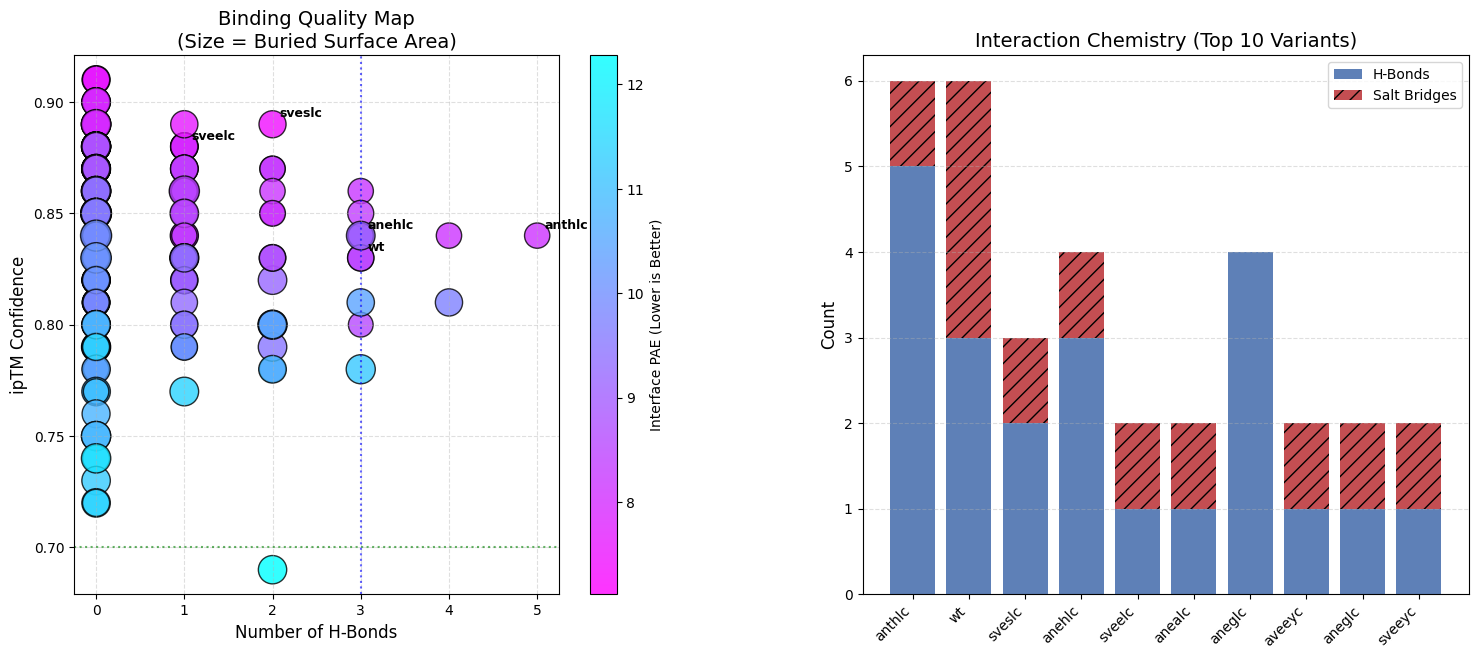

In [52]:
# --- Display Data ---
print("Top 10 Candidates by Probability Score:")
display(df.head(10))

# Save to CSV
csv_name = "af_batch_results_detailed.csv"
df.to_csv(os.path.join(OUTPUT_FOLDER, csv_name), index=False)
print(f"Full results saved to {csv_name}")

# --- Visualization Dashboard ---
# Set up a 2-panel figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
plt.subplots_adjust(wspace=0.3)

# --- LEFT PANEL: The "Quality Map" (Bubble Chart) ---
# X=H-Bonds, Y=ipTM, Color=PAE, Size=BSA
# Normalize BSA for bubble sizing (min size 50, max size 500)
bsa_sizes = df['BSA(Å²)'] / df['BSA(Å²)'].max() * 450 + 50

sc = ax1.scatter(
    df['H_Bonds'], 
    df['ipTM'], 
    c=df['PAE_Int'], 
    s=bsa_sizes, 
    cmap='cool_r', # Blue = Low PAE (Good), Pink = High PAE (Bad)
    alpha=0.8, 
    edgecolors='black',
    linewidth=1
)

# Add Colorbar
cbar = plt.colorbar(sc, ax=ax1)
cbar.set_label('Interface PAE (Lower is Better)', fontsize=10)

# Labels and Zones
ax1.set_xlabel('Number of H-Bonds', fontsize=12)
ax1.set_ylabel('ipTM Confidence', fontsize=12)
ax1.set_title('Binding Quality Map\n(Size = Buried Surface Area)', fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.4)

# Draw "Success Zone"
ax1.axhline(y=0.7, color='green', linestyle=':', alpha=0.6) # High Confidence Threshold
ax1.axvline(x=3, color='blue', linestyle=':', alpha=0.6)    # Physical Contact Threshold

# Annotate Top 5 Hits
for i, row in df.head(5).iterrows():
    ax1.annotate(
        f"{row['Variant']}", 
        (row['H_Bonds'], row['ipTM']),
        xytext=(5, 5), textcoords='offset points',
        fontsize=9, weight='bold'
    )

# --- RIGHT PANEL: Chemistry of Top 10 (Stacked Bar) ---
top_10 = df.head(10).copy()
# Create index for bars
x_pos = np.arange(len(top_10))

# Plot H-Bonds (Blue)
p1 = ax2.bar(x_pos, top_10['H_Bonds'], color='#4c72b0', label='H-Bonds', alpha=0.9)

# Plot Salt Bridges on top (Red)
p2 = ax2.bar(x_pos, top_10['Salt_Bridges'], bottom=top_10['H_Bonds'], color='#c44e52', label='Salt Bridges', hatch='//')

# Labels
ax2.set_xticks(x_pos)
ax2.set_xticklabels(top_10['Variant'], rotation=45, ha='right')
ax2.set_ylabel('Count', fontsize=12)
ax2.set_title('Interaction Chemistry (Top 10 Variants)', fontsize=14)
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

In [59]:
import ipywidgets as widgets
from IPython.display import display

# --- INTERACTIVE VISUALIZER WITH SEARCH ---

# 1. Prepare Master List of Options
# Format: ("Variant | Target | Score", Filename)
all_options = [
    (f"{r['Variant']} | {row['Loop_ID']} | {r['Target']} | Score: {r['Prob_Score']}", r['Filename']) 
    for i, r in df.iterrows()
]

def show_structure_and_stats(filename):
    """Displays the stats table and 3D structure."""
    if not filename:
        print("Select a variant to view.")
        return

    # A. Get Data
    try:
        row = df[df['Filename'] == filename].iloc[0]
        # Check if we have the CIF content loaded
        if filename not in cif_paths_map:
            print(f"Error: CIF data for {filename} not in memory. Did you re-run the batch loop?")
            return
        cif_data = cif_paths_map[filename]
    except IndexError:
        print("Error: Could not find data for selection.")
        return

    # B. Display Stats Table
    # Using HTML for a clean look
    stats_html = f"""
    <div style="border: 1px solid #ccc; padding: 10px; border-radius: 5px; background-color: #f9f9f9;">
        <div style="display: flex; gap: 20px; margin-bottom: 10px; font-family: monospace; font-size: 14px;">
            <div><b>Variant:</b> {row['Variant']}</div>
            <div><b>Loop:</b> {row['Loop_ID']}</div>
            <div><b>Target:</b> {row['Target']}</div>
            <div><b>Score:</b> <span style="color: {'green' if row['Prob_Score'] > 65 else 'red'}">{row['Prob_Score']}</span></div>
        </div>
        <table border="1" style="border-collapse: collapse; width: 100%; font-family: sans-serif; font-size: 12px;">
            <tr style="background-color: #e0e0e0;">
                <th>ipTM</th><th>PAE</th><th>BSA (Å²)</th><th>H-Bonds</th><th>Salt Bridges</th><th>Hydrophobic</th>
            </tr>
            <tr>
                <td>{row['ipTM']}</td>
                <td>{row['PAE_Int']}</td>
                <td>{row['BSA(Å²)']}</td>
                <td>{row['H_Bonds']}</td>
                <td>{row['Salt_Bridges']}</td>
                <td>{row['Hydrophobic']}</td>
            </tr>
        </table>
        <p style="margin-top:5px; font-size:10px; color: #666;">
            <i>Visualization: Ligand (Chain A) = Blue, Target (Chain B) = Orange.</i>
        </p>
    </div>
    """
    display(widgets.HTML(stats_html))

    # C. Render 3D Viewer
    view = py3Dmol.view(width=800, height=500)
    view.addModel(cif_data, 'cif')
    view.setStyle({'cartoon': {}})
    
    # Color Scheme
    view.setStyle({'chain': 'A'}, {'cartoon': {'color': 'blue'}})
    view.setStyle({'chain': 'B'}, {'cartoon': {'color': 'orange'}})

    # Highlight Interface
    # Show sidechains for residues within 5 Angstroms of the other chain
    view.addStyle({'within':{'distance': 5.0, 'sel':{'chain':'A'}}, 'sel':{'chain':'B'}}, {'stick':{'colorscheme':'orangeCarbon'}})
    view.addStyle({'within':{'distance': 5.0, 'sel':{'chain':'B'}}, 'sel':{'chain':'A'}}, {'stick':{'colorscheme':'blueCarbon'}})

    view.zoomTo()
    view.show()

# --- WIDGET LOGIC ---

# The Search Box
search_box = widgets.Text(
    value='',
    placeholder='Type to filter (e.g., "wt", "L1")',
    description='Filter:',
    style={'description_width': 'initial'},
    layout={'width': '300px'} 
)

# The Dropdown (Initially contains all options)
dropdown = widgets.Dropdown(
    options=all_options,
    description='Select:',
    style={'description_width': 'initial'},
    layout={'width': '500px'}
)

# Logic to link Search Box -> Dropdown
def on_search_change(change):
    search_term = change['new'].lower()
    
    # Filter the master list
    filtered_options = [opt for opt in all_options if search_term in opt[0].lower()]
    
    # Update dropdown
    if filtered_options:
        dropdown.options = filtered_options
        dropdown.value = filtered_options[0][1] # Select first match automatically
        dropdown.disabled = False
    else:
        # Handle no matches
        dropdown.options = [("No matches found", "")]
        dropdown.disabled = True

# Attach the observer
search_box.observe(on_search_change, names='value')

# Create the Output Container (This is where the structure appears)
out = widgets.interactive_output(show_structure_and_stats, {'filename': dropdown})

# Layout: Stack them vertically
ui = widgets.VBox([
    widgets.HBox([search_box, dropdown]), # Search and Select side-by-side
    out
])

display(ui)